In [2]:
import numpy as np
import skimage
import skimage.io
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
import shutil
import itertools
from pathlib import Path
import networkx as nx
from skimage import (
    data, restoration, util
)
import tifffile as tp

In [3]:
def file_list_from_img_folder(base_dir):
    file_list = pd.Series(glob.glob(os.path.join(base_dir,'Leap*')))
    file_list = pd.DataFrame(file_list,columns = ['path'])
    file_list['acquisition_ID'] = file_list.path.str.split('/').str[-1]
    file_list['Leap_ID'] = file_list.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
    file_list['Leap_ID'] = file_list['Leap_ID'].str[:7]#leap_ID should be Leap123, anything more is stripped
    biosamples_path = '/home/giuseppe/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response_RCB.csv'
    biosamples =pd.read_csv(biosamples_path)
    file_list = file_list.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient
    return file_list
base_dir = '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/non_preprocessed/'
file_list = file_list_from_img_folder(base_dir)

In [341]:
(file_list.path+'/Carboplatin.tiff')[0]

'/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/non_preprocessed/Leap081_8/Carboplatin.tiff'

In [3]:

file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension
# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*')
tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
acq_mark = pd.DataFrame(list(tb.filepath.str.split('/').str[-2:]),columns = ['acquisition','marker'])
acq_mark['marker'] = acq_mark.marker.str.replace('.tiff','')
marker_list = list(acq_mark.marker.unique())
marker_left_out = {'Carboplatin','DNA1','DNA2'}
marker_list_stain = list(set(marker_list).difference({'Carboplatin'}))
marker_list_row_norm = list(set(marker_list).difference(marker_left_out))


In [346]:
set(marker_list_stain).difference(marker_list_row_norm)

{'DNA1', 'DNA2'}

for each fov take the 95 percentile per marker, and take the median for all fovs with the same stain. 

In [ ]:
def extract_quantile_from_img(f):
    '''take quantile per fov. Use log1p trasform'''
    img = skimage.io.imread(f)
    img = np.log1p(img[img>0])
    q = np.quantile(img,0.98)
    return q
def load_and_rescale_by_quantile(f,q):
    img = skimage.io.imread(f)
    img = skimage.exposure.adjust_log(img)
    img = skimage.exposure.rescale_intensity(img, in_range=(0,q))
    return img    
def acq_Id_from_path(path):
    return path.split('/')[-2]
    
#file_list = file_list[file_list.Keep == 'y']
#process every channel independently, group images by staining date and normalise by quantile
groupkey = 'Stain'
all = {}

for k, indx in file_list.groupby(groupkey).groups.items():
    thresholds = []
    for marker in marker_list_stain:
        paths = file_list.loc[indx].path+'/'+marker+'.tiff'
        paths = paths.to_list()
        quantile = np.median(skimage.io.ImageCollection(paths,load_func=extract_quantile_from_img))
        #normalise each image according to the quantile
        
        imgs = skimage.io.ImageCollection(paths,load_func=lambda f:load_and_rescale_by_quantile(f,quantile))
        for path_inp,img in zip(imgs.files,imgs):
            path_out = path_inp.replace('non_preprocessed','rescaled')#is the name of the file where to save
            Path(os.path.dirname(path_out)).mkdir(parents=True, exist_ok=True)#creates the folder if missing
            i = path_out.rfind('.')
            #path_out =  path_out[:i]+'_temp'+path_out[i:]#add _temp to the name of the file
            if not Path(path_out).is_file():
                #if file does not exist, save it, otherwise skip
                skimage.io.imsave(path_out,img)
        thresholds.append(quantile)
    all[k] = thresholds 


In [ ]:
preprocessed_file_list = file_list_from_img_folder('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/rescaled/')
all_row = {}
for k, indx in preprocessed_file_list.groupby('Leap_ID').groups.items():
    thresholds = []
    #generate thresholds
    for marker in marker_list_row_norm:
        paths = preprocessed_file_list.loc[indx].path+'/'+marker+'.tiff'
        paths = paths.to_list()
        #compute the median per ROI and then the median of all ROIs in a Leap
        thr = np.median(skimage.io.ImageCollection(paths,load_func=lambda x:np.median(skimage.io.imread(x))))
        thresholds.append(thr)
    thr = np.sum(thresholds)
    all_row[k] = thresholds

    for marker in marker_list_row_norm:
        paths = preprocessed_file_list.loc[indx].path+'/'+marker+'.tiff'
        paths = paths.to_list()
        imgs = skimage.io.ImageCollection(paths)
        for path_inp,img in zip(imgs.files,imgs):
            path_out = path_inp.replace('rescaled','processed')#is the name of the file where to save. Drop the _temp in the name
            Path(os.path.dirname(path_out)).mkdir(parents=True, exist_ok=True)#creates the folder if missing
            if True:#not Path(path_out).is_file():
                #if file does not exist, save it, otherwise skip
                img_processed = skimage.exposure.rescale_intensity(img/thr,in_range=(0,1/thr))
                skimage.io.imsave(path_out,img_processed)
    for marker in set(marker_list_stain).difference(marker_list_row_norm):
        #process the DNAs
        #just copy the files
        paths = preprocessed_file_list.loc[indx].path+'/'+marker+'.tiff'
        paths = paths.to_list()
        for path_inp in paths:
            path_out = path_inp.replace('rescaled','processed')#is the name of the file where to save. Drop the _temp in the name
            shutil.copy(path_inp,path_out)
    

In [ ]:
name = '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/pre_processed/Leap020_5//CD20.tiff'
img = skimage.io.imread(name)

<Figure size 640x480 with 0 Axes>

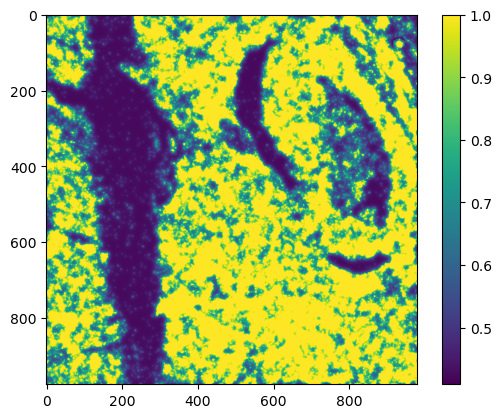

<Figure size 640x480 with 0 Axes>

In [333]:
name = '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/Leap020_5//CD20.tiff'
img = skimage.io.imread(name)
plt.imshow(img)
plt.colorbar()
plt.figure()


95% quantile by stain and marker.

<Axes: >

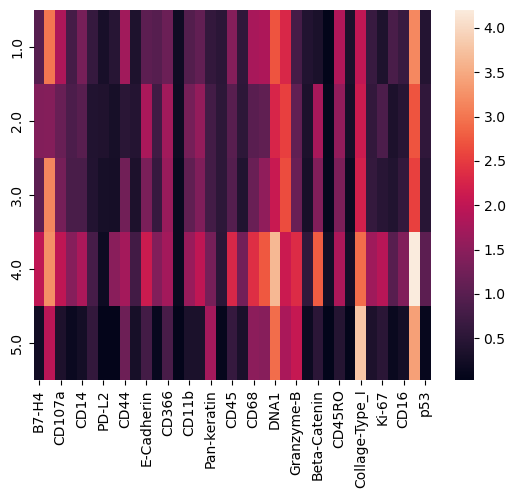

In [183]:
sns.heatmap(pd.DataFrame.from_dict(all,orient = 'index',columns  = marker_list))

In [338]:
a = pd.Series(glob.glob(os.path.join('../Img_Denoised/non_preprocessed/','Leap*')))
b = pd.Series(glob.glob(os.path.join('../Img_Denoised/processed/','Leap*')))
b

0       ../Img_Denoised/processed/Leap081_8
1       ../Img_Denoised/processed/Leap086_4
2       ../Img_Denoised/processed/Leap009_4
3       ../Img_Denoised/processed/Leap043_1
4       ../Img_Denoised/processed/Leap073_9
                       ...                 
697     ../Img_Denoised/processed/Leap052_7
698     ../Img_Denoised/processed/Leap006_2
699    ../Img_Denoised/processed/Leap088a_4
700     ../Img_Denoised/processed/Leap056_9
701    ../Img_Denoised/processed/Leap017_15
Length: 702, dtype: object

Median marker intensity by Leap (before processing)

<Axes: >

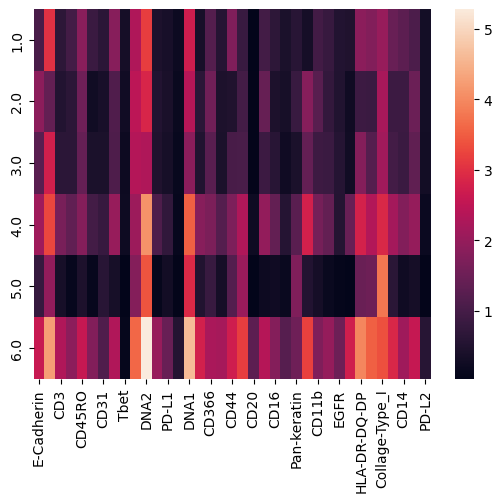

In [320]:
sns.heatmap(pd.DataFrame.from_dict(all,orient = 'index',columns  = marker_list_stain))

['/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/Leap001_8/p53_temp.tiff',
 '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/Leap001_9/p53_temp.tiff',
 '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/Leap001_10/p53_temp.tiff']

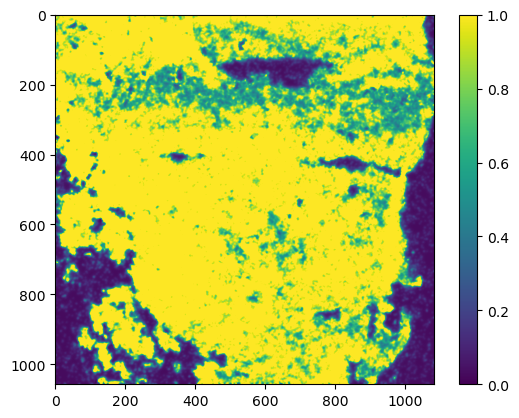

In [103]:
plt.imshow(skimage.exposure.rescale_intensity(skimage.io.ImageCollection(paths)[0]))
plt.colorbar()
skimage.io.ImageCollection(paths).files

In [19]:
file_list[file_list.Leap_ID=='LEAP005'].acquisition_ID

16      Leap005_2_9
118     Leap005_2_7
149     Leap005_2_3
194       Leap005_1
247     Leap005_2_6
252    Leap005_2_13
386     Leap005_2_5
417     Leap005_2_2
509     Leap005_2_1
515    Leap005_2_12
530       Leap005_2
541     Leap005_2_8
559     Leap005_2_4
581    Leap005_2_10
654    Leap005_2_11
Name: acquisition_ID, dtype: object

In [101]:
1/thr

0.03011561605392651

In [62]:
preprocessed_file_list = file_list_from_img_folder('/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/')
preprocessed_file_list.path[0]

'/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised/processed/Leap081_8'

array([1.27866907, 1.70960471, 2.31828709])

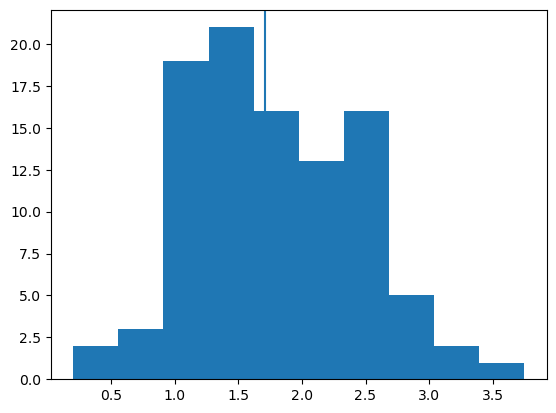

In [429]:
plt.hist(skimage.io.ImageCollection(paths.to_list(),load_func=loader_img))
plt.axvline(np.median(skimage.io.ImageCollection(paths.to_list(),load_func=loader_img)))
np.quantile(skimage.io.ImageCollection(paths.to_list(),load_func=loader_img),[0.25,0.5,0.75])

In [345]:
t_stat = []
imgs_all = skimage.io.imread_collection((file_list.path+'/CD45.tiff').tolist())
for img1,img2 in itertools.combinations(imgs,r = 2):
    t_stat +=[scipy.stats.kstest(img1.reshape(-1),img2.reshape(-1)).statistic]

In [346]:
distance = np.zeros((len(imgs_all),len(imgs_all)))
for (i,j),t in zip(itertools.combinations(range(len(imgs)),2),t_stat):
    distance[i][j] = t
distance = distance+distance.T

In [347]:
G = nx.from_numpy_array(1-distance)
edge_list = G.edges(data = True)
pos = pos = nx.spring_layout(G)
edge_list = [edge[:2]for edge in edge_list if edge[2]['weight']>0.9]


In [355]:
f = pd.Series(imgs_all.files).str.split('/').str[-2]
stains = file_list.sort_values(by = 'acquisition_ID',key=lambda x:x.map(dict(zip(f,f.index)))).Stain

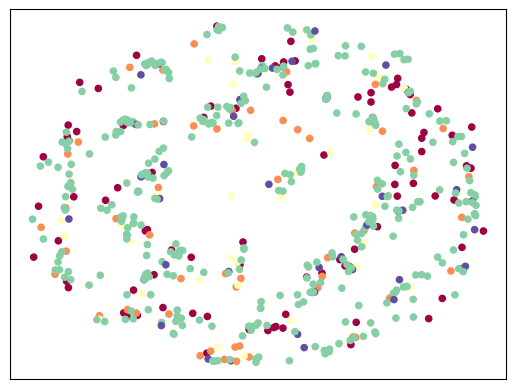

Signature:
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=None,
    node_size=300,
    node_color='#1f78b4',
    node_shape='o',
    alpha=None,
    cmap=None,
    vmin=None,
    vmax=None,
    ax=None,
    linewidths=None,
    edgecolors=None,
    label=None,
    margins=None,
)
Docstring:
Draw the nodes of the graph G.

This draws only the nodes of the graph G.

Parameters
----------
G : graph
    A networkx graph

pos : dictionary
    A dictionary with nodes as keys and positions as values.
    Positions should be sequences of length 2.

ax : Matplotlib Axes object, optional
    Draw the graph in the specified Matplotlib axes.

nodelist : list (default list(G))
    Draw only specified nodes

node_size : scalar or array (default=300)
    Size of nodes.  If an array it must be the same length as nodelist.

node_color : color or array of colors (default='#1f78b4')
    Node color. Can be a single color or a sequence of colors with the same
    length as nodelist. Color can be stri

In [357]:
nx.draw_networkx_nodes(G,pos,node_color=stains,node_size=20,cmap = 'Spectral')
nx.draw_networkx_nodes?

Different images from the same staining have different distribution for a given marker

[]

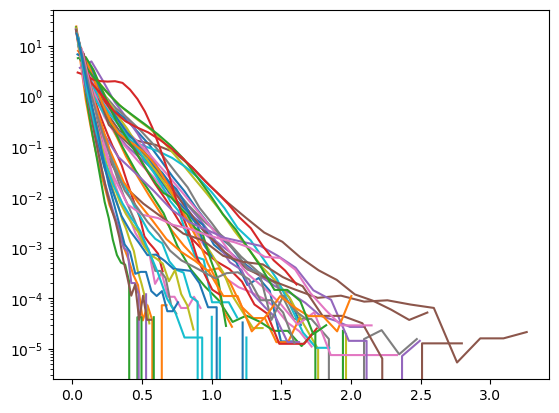

In [363]:

for img in imgs:
    h,b = np.histogram(np.log1p(img.flatten()),bins = 20,density=True)
    plt.plot((b[:-1]+b[1:])/2,h)
#_ = plt.hist(np.log1p(data),bins = 100,density=True,alpha = 0.9)
plt.semilogy()

0.30583202838897705

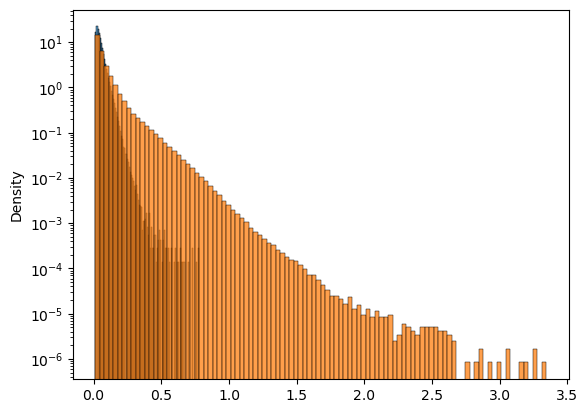

In [224]:
sns.histplot(np.log1p(img).reshape(-1),bins = 100,stat = 'density')
sns.histplot(np.log1p(data).reshape(-1),bins = 100,stat = 'density')
plt.semilogy()
q


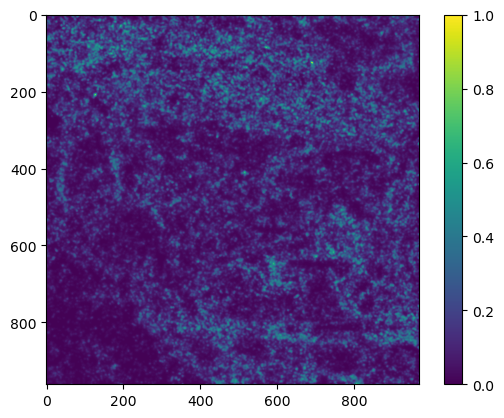

In [234]:
plt.imshow(skimage.exposure.equalize_adapthist(np.log1p(img)))
plt.colorbar()

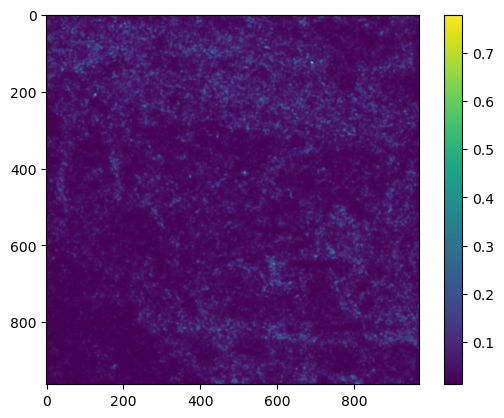

In [236]:
plt.imshow(np.log1p(img))
plt.colorbar()

<Axes: ylabel='Density'>

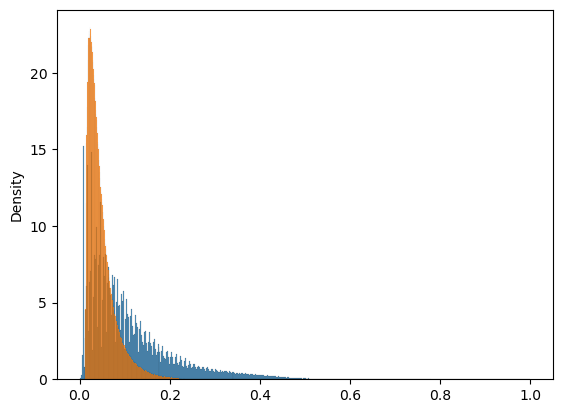

In [238]:
sns.histplot(skimage.exposure.equalize_adapthist(np.log1p(img),clip_limit=.01).reshape(-1),stat = 'density')
sns.histplot(np.log1p(img).reshape(-1),stat = 'density')


In [360]:
data

<module 'skimage.data' from '/home/giuseppe/anaconda3/lib/python3.9/site-packages/skimage/data/__init__.py'>